# 10 · Real-device TFLite operator profiling


This notebook analyzes the **80×80 full-INT8 model on the physical ESP32-CAM**. Each row is a fused TFLite Micro operator measured with `esp_timer_get_time()` across 20 batch-1 invocations after two warm-up invocations. It is not a desktop benchmark. The absolute timings include lightweight profiler hooks; use them for operator attribution and controlled instrumented-build comparisons.

If the artifacts are absent, activate ESP-IDF and run:

```bash
source scripts/activate_esp_idf.sh
scripts/profile_esp32_model.sh artifacts/fast_80/models/vww_mobilenetv1_80_int8.tflite 80 fast_80 /dev/cu.usbserial-130
```

In [1]:
from pathlib import Path
import sys

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'configs/base.yaml').exists())
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

from vww_esp32.device_profiling import load_device_profile

sns.set_theme(style='whitegrid', context='notebook')
PROFILE_ROOT = ROOT / 'artifacts' / 'device_profiles'
ROOT


PosixPath('/Volumes/VM_SSD/Machine Learning/visual-wake-word-esp32')

In [2]:
profile_dir = PROFILE_ROOT / 'fast_80'
operator_profile, device = load_device_profile(profile_dir)
summary = pd.DataFrame({
    'Metric': ['Variant', 'Input', 'Batch', 'Samples', 'Invoke mean', 'Invoke range',
               'Profiled operator sum', 'Unprofiled remainder', 'Arena reserved',
               'Arena used', 'Arena utilization', 'TFLite live activation peak',
               'Internal SRAM free / largest block', 'Mapped PSRAM free',
               'Model bytes', 'Estimated MACs', 'Operators'],
    'Value': [device['variant'], device['input'], device['batch'], device['samples'],
              f"{device['mean_us']/1000:.3f} ms",
              f"{device['min_us']/1000:.3f}-{device['max_us']/1000:.3f} ms",
              f"{device['operator_sum_mean_us']/1000:.3f} ms",
              f"{device['unprofiled_mean_us']/1000:.3f} ms",
              f"{device['tensor_arena_reserved_bytes']:,} B",
              f"{device['arena_used_bytes']:,} B",
              f"{device['tensor_arena_utilization']:.1%}",
              f"{device['tflite_live_activation_peak_bytes']:,} B",
              f"{device['ready_internal_free_bytes']:,} / {device['ready_internal_largest_bytes']:,} B",
              f"{device['ready_psram_free_bytes']:,} B", f"{device['model_bytes']:,} B",
              f"{device['estimated_macs']:,}", device['operators']],
})
display(summary.style.hide(axis='index'))

Metric,Value
Variant,fast_80
Input,80x80x3
Batch,1
Samples,20
Invoke mean,455.546 ms
Invoke range,453.364-459.697 ms
Profiled operator sum,454.558 ms
Unprofiled remainder,0.989 ms
Arena reserved,"358,400 B"
Arena used,"69,068 B"


## Every deployed operator

In [3]:
columns = ['index', 'operator', 'input_shape', 'output_shape', 'input_activation_bytes',
           'output_activation_bytes', 'activation_io_bytes',
           'live_activation_before_bytes', 'live_activation_during_bytes',
           'live_activation_after_bytes', 'constant_bytes', 'estimated_macs',
           'mean_ms', 'min_ms', 'max_ms', 'latency_share', 'mmacs_per_second']
display(operator_profile[columns].style.format({
    'input_activation_bytes': '{:,.0f}', 'output_activation_bytes': '{:,.0f}',
    'activation_io_bytes': '{:,.0f}', 'live_activation_before_bytes': '{:,.0f}',
    'live_activation_during_bytes': '{:,.0f}', 'live_activation_after_bytes': '{:,.0f}',
    'constant_bytes': '{:,.0f}', 'estimated_macs': '{:,.0f}',
    'mean_ms': '{:.3f}', 'min_ms': '{:.3f}', 'max_ms': '{:.3f}',
    'latency_share': '{:.1%}', 'mmacs_per_second': '{:.2f}',
}, na_rep='—').background_gradient(subset=['mean_ms', 'live_activation_during_bytes'], cmap='Reds'))

,index,operator,input_shape,output_shape,input_activation_bytes,output_activation_bytes,activation_io_bytes,live_activation_before_bytes,live_activation_during_bytes,live_activation_after_bytes,constant_bytes,estimated_macs,mean_ms,min_ms,max_ms,latency_share,mmacs_per_second
0,0,MUL,1x80x80x3,1x80x80x3,"19,200","19,200","38,400","19,200","38,400","19,200",1,0,12.878,12.183,15.843,2.8%,—
1,1,ADD,1x80x80x3,1x80x80x3,"19,200","19,200","38,400","19,200","38,400","19,200",1,0,24.752,23.741,26.412,5.4%,—
2,2,CONV_2D,1x80x80x3,1x40x40x8,"19,200","12,800","32,000","19,200","32,000","12,800",248,"345,600",47.748,46.737,49.312,10.5%,7.24
3,3,DEPTHWISE_CONV_2D,1x40x40x8,1x40x40x8,"12,800","12,800","25,600","12,800","25,600","12,800",104,"115,200",16.961,16.283,19.007,3.7%,6.79
4,4,CONV_2D,1x40x40x8,1x40x40x16,"12,800","25,600","38,400","12,800","38,400","25,600",192,"204,800",34.592,33.606,35.644,7.6%,5.92
5,5,DEPTHWISE_CONV_2D,1x40x40x16,1x20x20x16,"25,600","6,400","32,000","25,600","32,000","6,400",208,"57,600",9.586,9.172,11.221,2.1%,6.01
6,6,CONV_2D,1x20x20x16,1x20x20x32,"6,400","12,800","19,200","6,400","19,200","12,800",640,"204,800",54.282,53.482,55.336,11.9%,3.77
7,7,DEPTHWISE_CONV_2D,1x20x20x32,1x20x20x32,"12,800","12,800","25,600","12,800","25,600","12,800",416,"115,200",15.163,14.538,16.733,3.3%,7.60
8,8,CONV_2D,1x20x20x32,1x20x20x32,"12,800","12,800","25,600","12,800","25,600","12,800","1,152","409,600",31.589,30.669,33.331,6.9%,12.97
9,9,DEPTHWISE_CONV_2D,1x20x20x32,1x10x10x32,"12,800","3,200","16,000","12,800","16,000","3,200",416,"28,800",5.066,4.900,6.012,1.1%,5.69


## Per-operator activation memory timeline

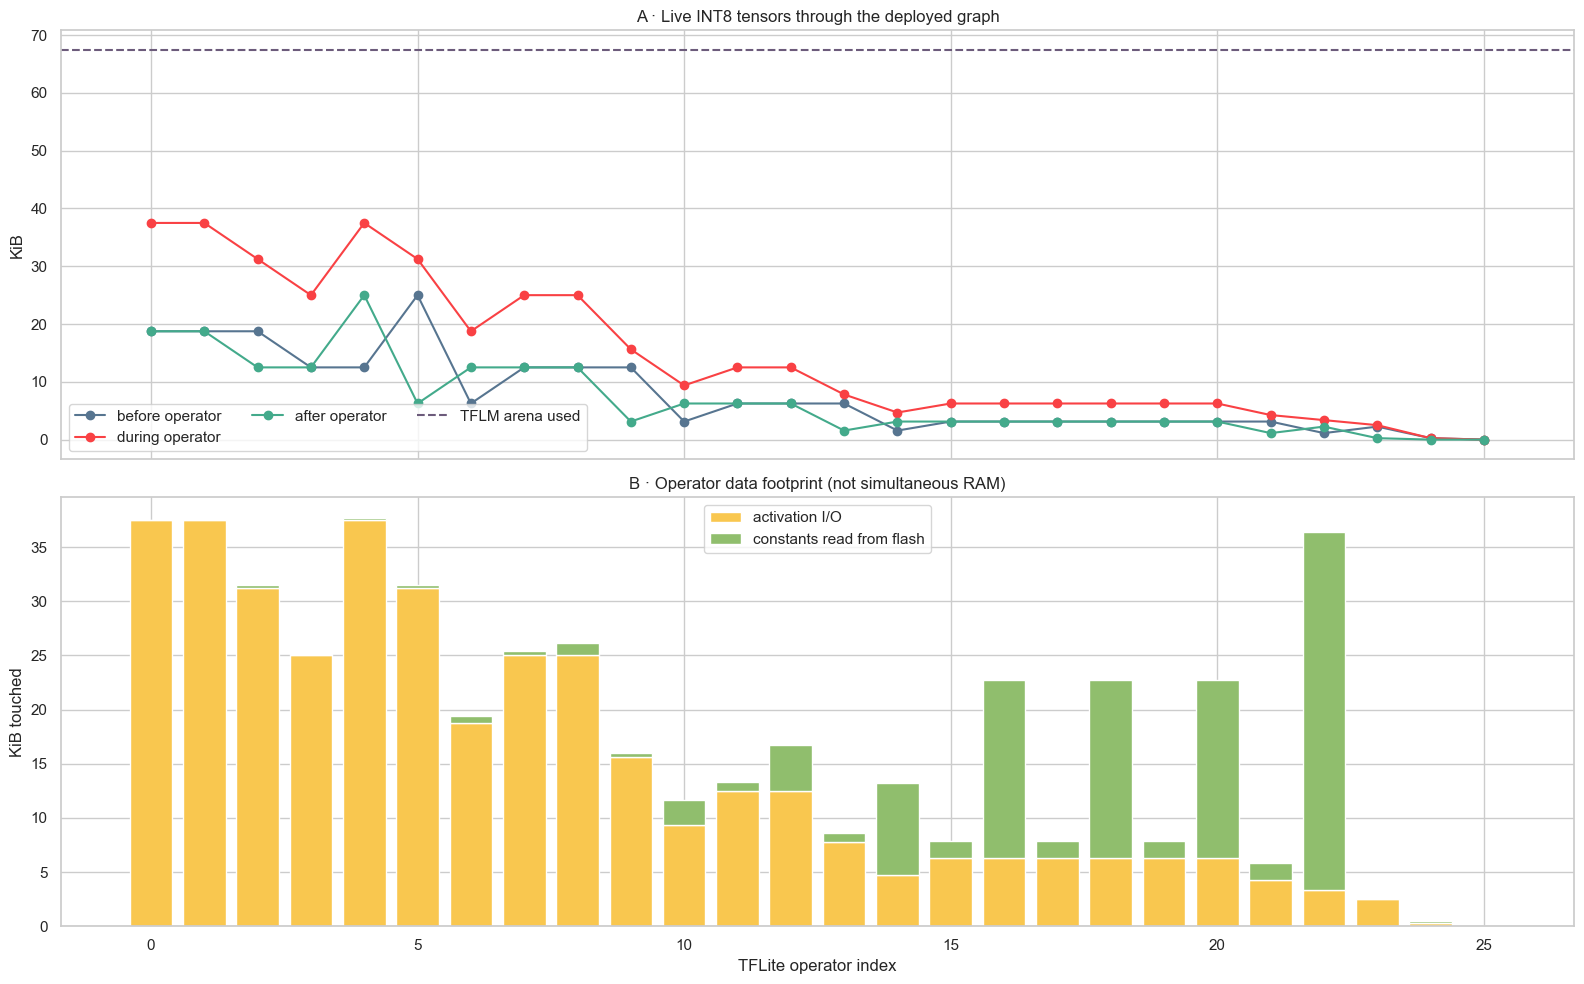

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
x = operator_profile['index']
for field, label, color in [
    ('live_activation_before_bytes', 'before operator', '#577590'),
    ('live_activation_during_bytes', 'during operator', '#F94144'),
    ('live_activation_after_bytes', 'after operator', '#43AA8B')]:
    axes[0].plot(x, operator_profile[field] / 1024, marker='o', label=label, color=color)
axes[0].axhline(device['arena_used_bytes']/1024, color='#6C5B7B', linestyle='--', label='TFLM arena used')
axes[0].set(title='A · Live INT8 tensors through the deployed graph', ylabel='KiB')
axes[0].legend(ncol=3)
axes[1].bar(x, operator_profile.activation_io_bytes / 1024, color='#F9C74F', label='activation I/O')
axes[1].bar(x, operator_profile.constant_bytes / 1024, bottom=operator_profile.activation_io_bytes / 1024,
            color='#90BE6D', label='constants read from flash')
axes[1].set(title='B · Operator data footprint (not simultaneous RAM)',
            xlabel='TFLite operator index', ylabel='KiB touched')
axes[1].legend()
plt.tight_layout()
fig.savefig(profile_dir / 'operator_memory_timeline.png', dpi=180, bbox_inches='tight')
plt.show()

## Device memory hierarchy

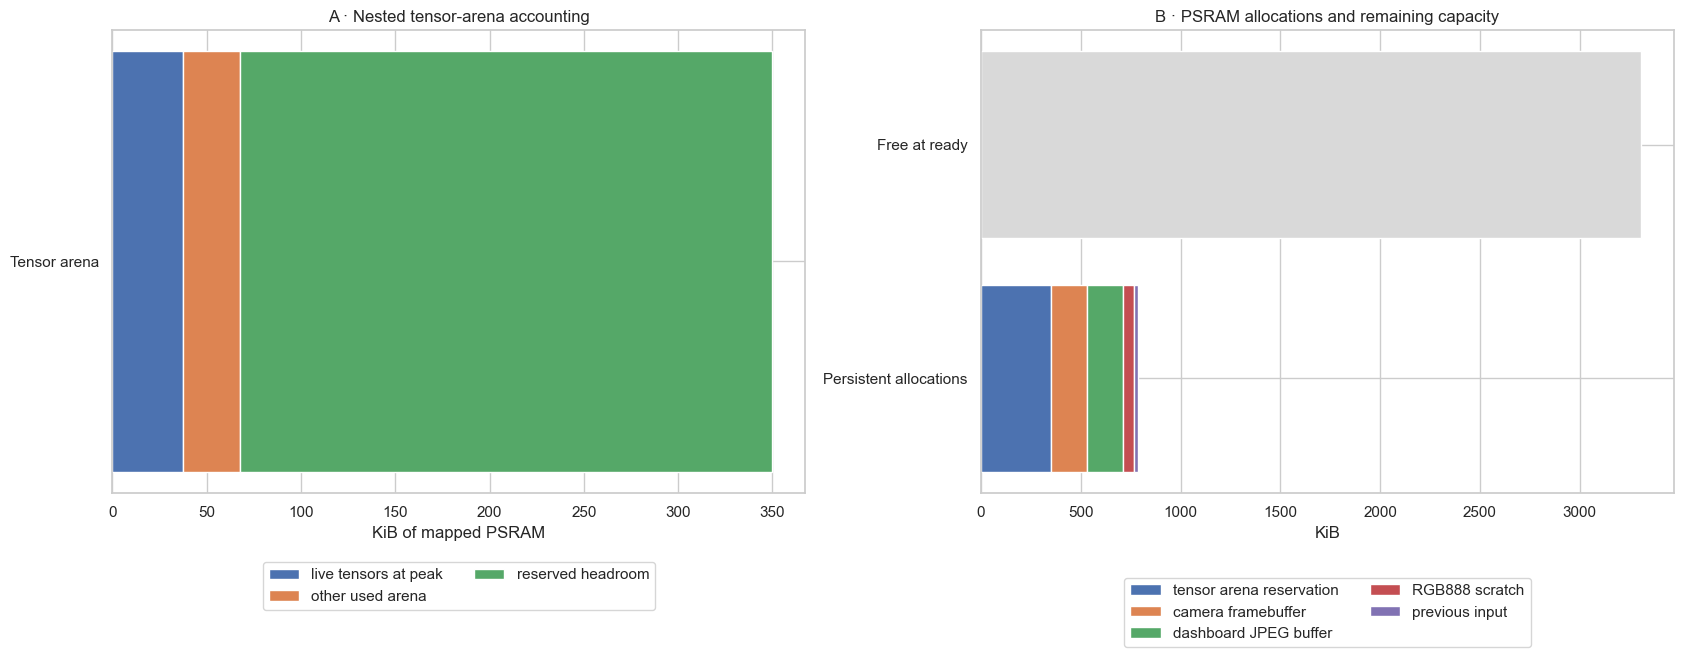

In [5]:
memory = pd.read_csv(profile_dir / 'memory_summary.csv')
fig, axes = plt.subplots(1, 2, figsize=(17, 7))
arena_parts = pd.Series({
    'live tensors at peak': device['tflite_live_activation_peak_bytes'],
    'other used arena': device['arena_bytes_beyond_live_tensors'],
    'reserved headroom': device['tensor_arena_headroom_bytes'],
}) / 1024
left = 0
for label, value in arena_parts.items():
    axes[0].barh(['Tensor arena'], [value], left=left, label=label)
    left += value
axes[0].set(title='A · Nested tensor-arena accounting', xlabel='KiB of mapped PSRAM')
axes[0].legend(loc='lower center', bbox_to_anchor=(0.5, -0.27), ncol=2)
psram_parts = pd.Series({
    'tensor arena reservation': device['tensor_arena_reserved_bytes'],
    'camera framebuffer': device['camera_framebuffer_bytes'],
    'dashboard JPEG buffer': device['dashboard_jpeg_buffer_bytes'],
    'RGB888 scratch': device['rgb888_scratch_bytes'],
    'previous input': device['input_tensor_bytes'],
}) / 1024
left = 0
for label, value in psram_parts.items():
    axes[1].barh(['Persistent allocations'], [value], left=left, label=label)
    left += value
axes[1].barh(['Free at ready'], [device['ready_psram_free_bytes']/1024], color='#D9D9D9')
axes[1].set(title='B · PSRAM allocations and remaining capacity', xlabel='KiB')
axes[1].legend(loc='lower center', bbox_to_anchor=(0.5, -0.35), ncol=2)
plt.tight_layout()
fig.savefig(profile_dir / 'device_memory_hierarchy.png', dpi=180, bbox_inches='tight')
plt.show()

## Where inference time goes

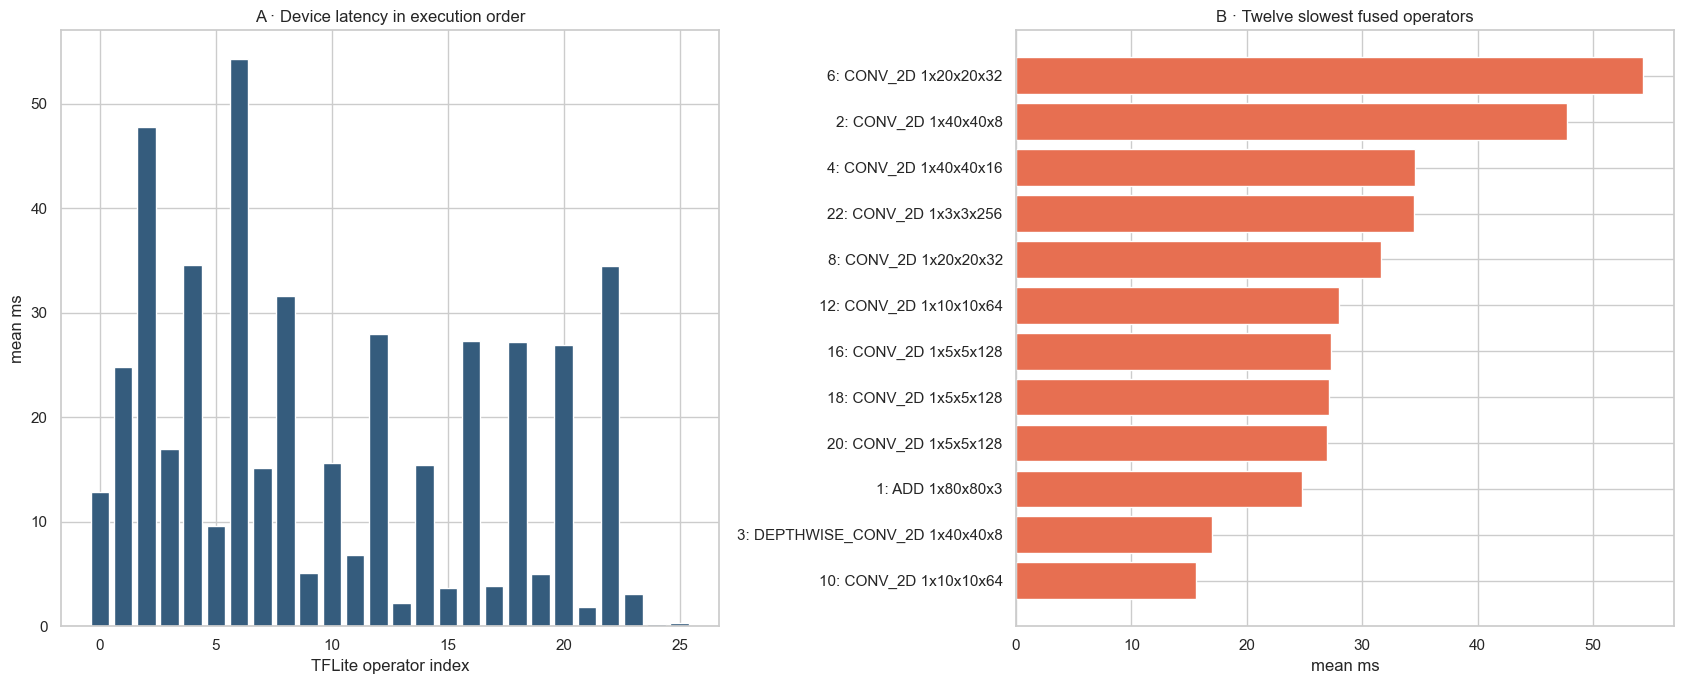

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(17, 7))
by_index = operator_profile.copy()
axes[0].bar(by_index['index'], by_index['mean_ms'], color='#355C7D')
axes[0].set(title='A · Device latency in execution order', xlabel='TFLite operator index', ylabel='mean ms')
top = operator_profile.nlargest(12, 'mean_ms').sort_values('mean_ms')
labels = top.apply(lambda row: f"{int(row['index'])}: {row['operator']} {row['output_shape']}", axis=1)
axes[1].barh(labels, top['mean_ms'], color='#E76F51')
axes[1].set(title='B · Twelve slowest fused operators', xlabel='mean ms', ylabel='')
plt.tight_layout()
figure = profile_dir / 'operator_latency.png'
fig.savefig(figure, dpi=180, bbox_inches='tight')
plt.show()

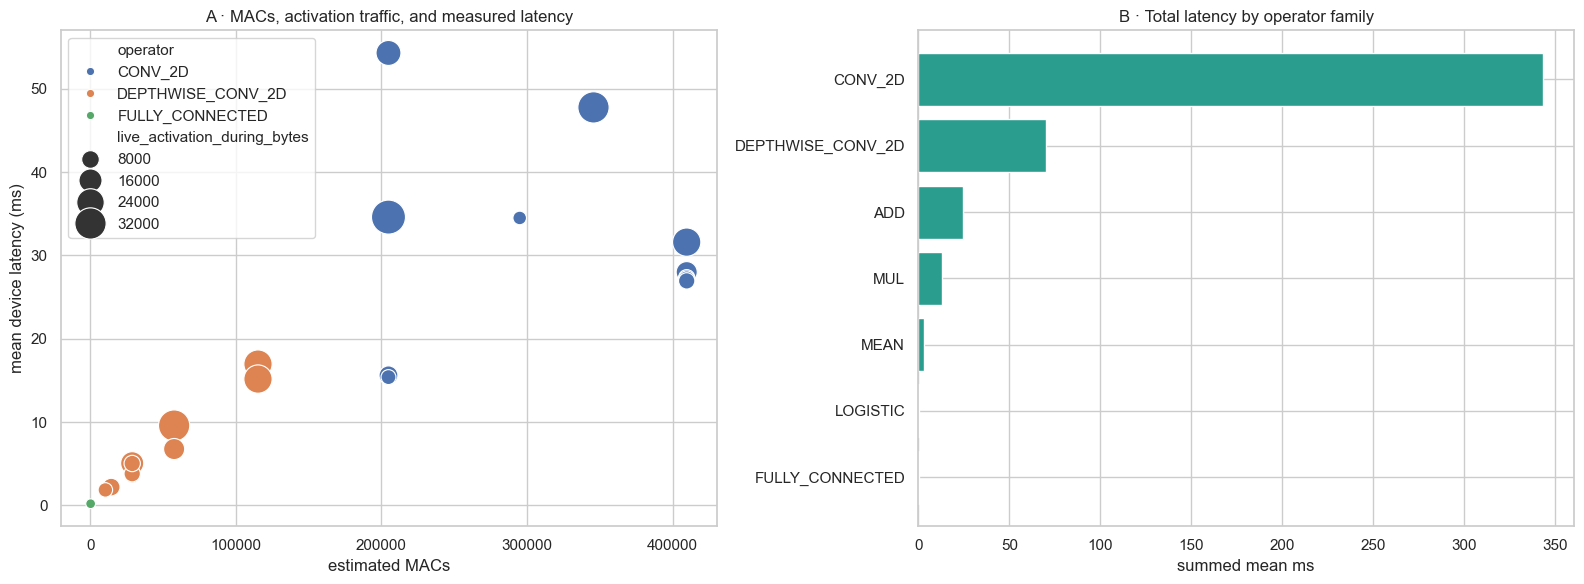

In [7]:
compute = operator_profile[operator_profile.estimated_macs > 0].copy()
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.scatterplot(data=compute, x='estimated_macs', y='mean_ms', hue='operator',
                size='live_activation_during_bytes', sizes=(50, 600), ax=axes[0])
axes[0].set(title='A · MACs, activation traffic, and measured latency',
            xlabel='estimated MACs', ylabel='mean device latency (ms)')
grouped = operator_profile.groupby('operator').agg(mean_ms=('mean_ms', 'sum'),
    macs=('estimated_macs', 'sum'), count=('index', 'count')).sort_values('mean_ms')
axes[1].barh(grouped.index, grouped.mean_ms, color='#2A9D8F')
axes[1].set(title='B · Total latency by operator family', xlabel='summed mean ms', ylabel='')
plt.tight_layout()
figure = profile_dir / 'operator_resource_relationship.png'
fig.savefig(figure, dpi=180, bbox_inches='tight')
plt.show()

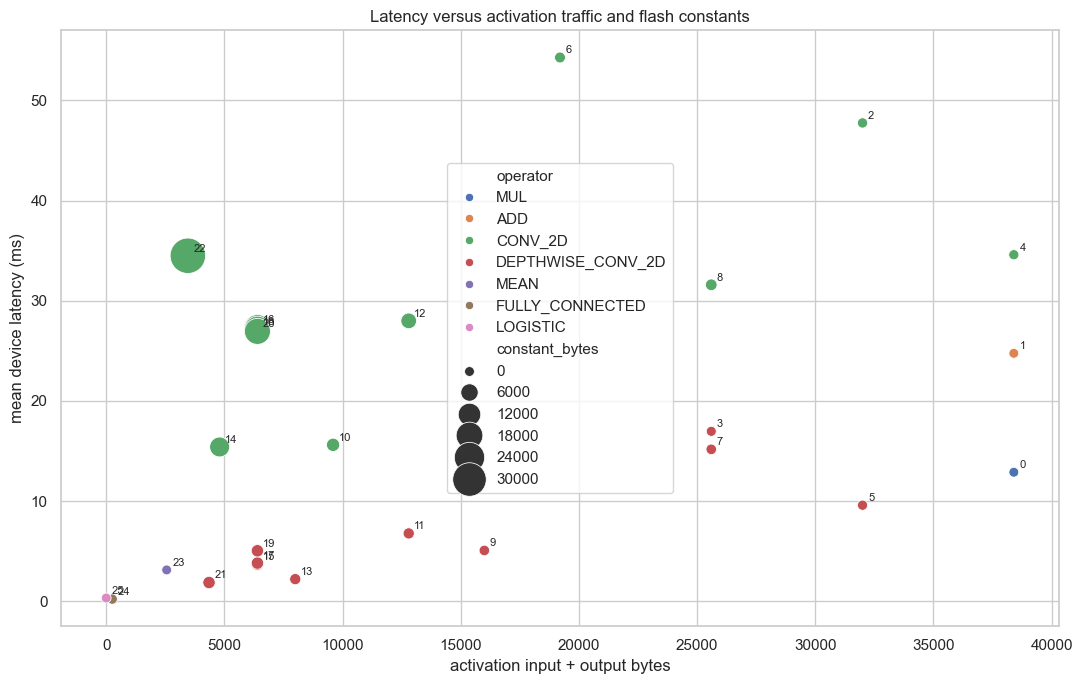

In [8]:
fig, ax = plt.subplots(figsize=(11, 7))
sns.scatterplot(data=operator_profile, x='activation_io_bytes', y='mean_ms',
                hue='operator', size='constant_bytes', sizes=(50, 650), ax=ax)
for _, row in operator_profile.iterrows():
    ax.annotate(str(int(row['index'])), (row.activation_io_bytes, row.mean_ms),
                xytext=(4, 3), textcoords='offset points', fontsize=8)
ax.set(title='Latency versus activation traffic and flash constants',
       xlabel='activation input + output bytes', ylabel='mean device latency (ms)')
plt.tight_layout()
fig.savefig(profile_dir / 'latency_memory_relationship.png', dpi=180, bbox_inches='tight')
plt.show()

## Measured bottleneck report

In [9]:
slowest = operator_profile.nlargest(5, 'mean_ms')
conv_share = operator_profile.loc[operator_profile.operator.isin(['CONV_2D', 'DEPTHWISE_CONV_2D']), 'mean_us'].sum() / operator_profile.mean_us.sum()
display(Markdown(f"""
- Convolution and depthwise convolution consume **{conv_share:.1%}** of profiled operator time.
- The slowest operator is index **{int(slowest.iloc[0]['index'])}** `{slowest.iloc[0]['operator']}` with output `{slowest.iloc[0]['output_shape']}`, taking **{slowest.iloc[0]['mean_ms']:.3f} ms**.
- The five slowest operators consume **{slowest.mean_us.sum()/operator_profile.mean_us.sum():.1%}** of profiled operator time.
- Peak simultaneous live tensors are **{device['tflite_live_activation_peak_bytes']/1024:.1f} KiB**; TFLM uses **{device['arena_used_bytes']/1024:.1f} KiB** inside a **{device['tensor_arena_reserved_bytes']/1024:.0f} KiB** PSRAM arena.
- The board has **{device['ready_internal_free_bytes']/1024:.1f} KiB** internal SRAM free, but its largest block is only **{device['ready_internal_largest_bytes']/1024:.1f} KiB**.
- Optimize channel counts and early feature-map traffic before changing the classifier head.
- See `{profile_dir / 'DEVICE_LAYER_PROFILE_REPORT.md'}` for the persisted report.
"""))


- Convolution and depthwise convolution consume **90.9%** of profiled operator time.
- The slowest operator is index **6** `CONV_2D` with output `1x20x20x32`, taking **54.282 ms**.
- The five slowest operators consume **44.6%** of profiled operator time.
- Peak simultaneous live tensors are **37.5 KiB**; TFLM uses **67.4 KiB** inside a **350 KiB** PSRAM arena.
- The board has **65.3 KiB** internal SRAM free, but its largest block is only **60.0 KiB**.
- Optimize channel counts and early feature-map traffic before changing the classifier head.
- See `/Volumes/VM_SSD/Machine Learning/visual-wake-word-esp32/artifacts/device_profiles/fast_80/DEVICE_LAYER_PROFILE_REPORT.md` for the persisted report.
